In [1]:
import numpy as np
import torch
#Seeding for deterministic results i.e. showing same output 
RANDOM_SEED = 64
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
   torch.cuda.manual_seed(RANDOM_SEED)
   torch.cuda.manual_seed_all(RANDOM_SEED) 
   torch.backends.cudnn.deterministic = True  
   torch.backends.cudnn.benchmark = False

# LOAD DATASET

In [ ]:
files = 'Data/extended_synthetic_corpus/'

In [3]:
import os
import pandas as pd
import json

data = []
for file in os.listdir(files):
  file_path = os.path.join(files, file)
  LLM_label = file_path.split('_')[-1].split('.')[0]
  with open(file_path, encoding='utf-8') as f:
    file_data = json.load(f)
    for item in file_data:
        data.append([item['text'], item['label'], LLM_label])

df = pd.DataFrame(data, columns=['text', 'label', 'LLM'])

In [4]:
from sklearn.model_selection import train_test_split

#df['stratify'] = df['label'] + df['LLM']

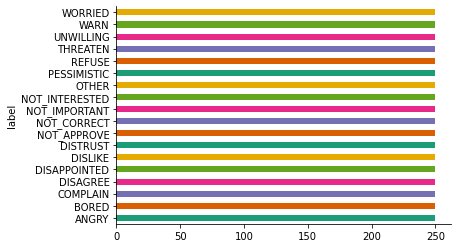

In [5]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

# SPLIT INTO STRATIFIED TRAIN, VALID, AND TEST DATASETS

In [6]:
train, temp = train_test_split(df, test_size=0.3, stratify=df[["label", "LLM"]], random_state=42)
validation, test = train_test_split(temp, test_size=2/3, stratify=temp[["label", "LLM"]], random_state=42)

# PREPARE FOR EXPERIMENTS: DROP 'STRATIFY' COLUMN AND RANDOMIZE DATASETS

In [7]:
df_train = train.sample(frac=1)
df_validation = validation.sample(frac=1)
df_test = test.sample(frac=1)

In [8]:
df_train

,text,label,LLM
2723,I don't think that's quite accurate 🤔,NOT_CORRECT,CHATGPT
4243,"🐀 Don't tempt fate, or the mousy little secret...",THREATEN,OPENCHAT
1456,I really must object to how early it gets dark...,COMPLAIN,CHATGPT
726,Volunteering for yet another committee? Regret...,REFUSE,MIXTRAL
4379,Why are gym memberships so expensive? There'...,DISLIKE,GEMINI
...,...,...,...
875,No way! I'm not going to jump off that cliff. ...,REFUSE,BING
3729,I just don't get the hype around certain popul...,NOT_APPROVE,OPENCHAT
4296,"I really can't agree with that, sorry 🤷‍♂️ #No...",DISAGREE,CHATGPT
1573,So what if my phone case is a little scratched...,NOT_IMPORTANT,GEMINI


# MACHINE LEARNING EXPERIMENT WITH MULTINOMIAL NAIVE BAYES

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import TweetTokenizer

def tokenizer(text):
    tok = TweetTokenizer()
    return tok.tokenize(text)
cv = CountVectorizer(stop_words='english',ngram_range = (1,2), tokenizer=tokenizer)

## Experiment with extended synthetic corpus

In [10]:
X_train = cv.fit_transform(df_train['text'])
X_valid = cv.transform(df_validation['text'])
X_test = cv.transform(df_test['text'])

y_train = df_train['label']
y_valid = df_validation['label']
y_test = df_test['label']

In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

clf = MultinomialNB()

param_grid = {'alpha': [0.1, 1, 10]}
grid_search = GridSearchCV(clf, param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
val_score = grid_search.score(X_valid, y_valid)
print("Validation accuracy:", val_score)

Best hyperparameters: {'alpha': 1}
Validation accuracy: 0.6044444444444445


In [12]:
clf = MultinomialNB(alpha=val_score)
clf.fit(X_train, y_train)

test_score = clf.score(X_test, y_test)
print("Test accuracy:", test_score)

Test accuracy: 0.6277777777777778


In [13]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)
report = classification_report(y_test, y_pred)

print(report)

                precision    recall  f1-score   support

         ANGRY       0.58      0.70      0.64        50
         BORED       0.73      0.54      0.62        50
      COMPLAIN       0.66      0.42      0.51        50
      DISAGREE       0.69      0.72      0.71        50
  DISAPPOINTED       0.72      0.66      0.69        50
       DISLIKE       0.57      0.42      0.48        50
      DISTRUST       0.65      0.68      0.67        50
   NOT_APPROVE       0.72      0.42      0.53        50
   NOT_CORRECT       0.63      0.62      0.63        50
 NOT_IMPORTANT       0.49      0.64      0.56        50
NOT_INTERESTED       0.60      0.60      0.60        50
         OTHER       0.57      0.68      0.62        50
   PESSIMISTIC       0.47      0.56      0.51        50
        REFUSE       0.44      0.72      0.55        50
      THREATEN       0.75      0.78      0.76        50
     UNWILLING       0.75      0.78      0.76        50
          WARN       0.75      0.72      0.73  

In [14]:
clf_report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
df_results = pd.DataFrame(clf_report).transpose()
with open(r'classification_report_extended_model_naive_bayes.csv', 'w') as csv_file:
    df_results.to_csv(path_or_buf=csv_file)

In [15]:
df_test['predicted_label'] = y_pred
df_test.to_csv('preds_extended_model_naive_bayes.tsv',header =True, sep = '\t',index=False)

## Experiment with basic synthetic corpus

In [ ]:
basic_function_dataset_file = 'Data/neg_att_funct_basic.txt'
basic_function_df = pd.read_csv(basic_function_dataset_file, sep =';')

In [17]:
basic_function_df

,text,label
0,I'm hardly interested in it,NOT_INTERESTED
1,I'm hardly interested,NOT_INTERESTED
2,I'm not very interested in it,NOT_INTERESTED
3,I'm not very interested,NOT_INTERESTED
4,I'm not interested in it,NOT_INTERESTED
...,...,...
897,you could do it,OTHER
898,you look nice,OTHER
899,you look smart,OTHER
900,you're right,OTHER


In [18]:
df_train_basic = basic_function_df.sample(frac=1)

In [19]:
X_train_basic = cv.transform(df_train_basic['text'])
y_train_basic = df_train_basic['label']

In [20]:
clf = MultinomialNB(alpha=val_score)
param_grid = {'alpha': [0.1, 1, 10]}
grid_search = GridSearchCV(clf, param_grid, cv=5)
grid_search.fit(X_train_basic, y_train_basic)

print("Best hyperparameters:", grid_search.best_params_)
val_score = grid_search.score(X_valid, y_valid)
print("Validation accuracy:", val_score)

Best hyperparameters: {'alpha': 0.1}
Validation accuracy: 0.2822222222222222


In [21]:
clf = MultinomialNB(alpha=val_score)
clf.fit(X_train_basic, y_train_basic)

test_score = clf.score(X_test, y_test)
print("Test accuracy:", test_score)

Test accuracy: 0.2811111111111111


In [22]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)
report = classification_report(y_test, y_pred)

print(report)

                precision    recall  f1-score   support

         ANGRY       0.65      0.30      0.41        50
         BORED       0.52      0.24      0.33        50
      COMPLAIN       0.60      0.30      0.40        50
      DISAGREE       0.66      0.38      0.48        50
  DISAPPOINTED       1.00      0.22      0.36        50
       DISLIKE       0.58      0.30      0.39        50
      DISTRUST       1.00      0.08      0.15        50
   NOT_APPROVE       0.33      0.22      0.27        50
   NOT_CORRECT       0.38      0.30      0.33        50
 NOT_IMPORTANT       0.55      0.12      0.20        50
NOT_INTERESTED       0.50      0.06      0.11        50
         OTHER       0.09      0.76      0.16        50
   PESSIMISTIC       0.75      0.36      0.49        50
        REFUSE       0.14      0.44      0.21        50
      THREATEN       0.31      0.10      0.15        50
     UNWILLING       0.92      0.24      0.38        50
          WARN       0.90      0.18      0.30  

In [23]:
clf_report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
df_results = pd.DataFrame(clf_report).transpose()
with open(r'classification_report_basic_model_naive_bayes.csv', 'w') as csv_file:
    df_results.to_csv(path_or_buf=csv_file)

In [24]:
df_test['predicted_label'] = y_pred
df_test.to_csv('preds_basic_model_naive_bayes.tsv',header =True, sep = '\t',index=False)

## Dummy classifier

In [25]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier()
dummy.fit(X_train_basic, y_train_basic)

y_pred = dummy.predict(X_test)
test_score = dummy.score(X_test, y_test)
print("Test accuracy:", test_score)

Test accuracy: 0.05555555555555555


In [26]:
from sklearn.metrics import classification_report

y_pred = dummy.predict(X_test)
report = classification_report(y_test, y_pred)

print(report)

                precision    recall  f1-score   support

         ANGRY       0.00      0.00      0.00        50
         BORED       0.00      0.00      0.00        50
      COMPLAIN       0.00      0.00      0.00        50
      DISAGREE       0.00      0.00      0.00        50
  DISAPPOINTED       0.00      0.00      0.00        50
       DISLIKE       0.00      0.00      0.00        50
      DISTRUST       0.00      0.00      0.00        50
   NOT_APPROVE       0.00      0.00      0.00        50
   NOT_CORRECT       0.00      0.00      0.00        50
 NOT_IMPORTANT       0.00      0.00      0.00        50
NOT_INTERESTED       0.00      0.00      0.00        50
         OTHER       0.06      1.00      0.11        50
   PESSIMISTIC       0.00      0.00      0.00        50
        REFUSE       0.00      0.00      0.00        50
      THREATEN       0.00      0.00      0.00        50
     UNWILLING       0.00      0.00      0.00        50
          WARN       0.00      0.00      0.00  

/home/njfernandez/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/njfernandez/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/njfernandez/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# DEEP LEARNING EXPERIMENT WITH TRANSFORMERS

## Experiment with extended synthetic corpus

In [27]:
from datasets import Dataset, DatasetDict

dataset = DatasetDict({
    "train": Dataset.from_pandas(df_train.reset_index(drop=True)),
    "valid": Dataset.from_pandas(df_validation.reset_index(drop=True)),
     "test": Dataset.from_pandas(df_test.reset_index(drop=True))
    }
    )
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'LLM'],
        num_rows: 3150
    })
    valid: Dataset({
        features: ['text', 'label', 'LLM'],
        num_rows: 450
    })
    test: Dataset({
        features: ['text', 'label', 'LLM', 'predicted_label'],
        num_rows: 900
    })
})

In [28]:
dataset['test'][0]

{'text': '😰 Stressed over a huge project due soon 💻📅',
 'label': 'WORRIED',
 'LLM': 'MIXTRAL',
 'predicted_label': 'OTHER'}

In [29]:
dataset = dataset.class_encode_column("label")
labels = dataset['train'].features['label']
print(labels.names)

Casting to class labels:   0%|          | 0/3150 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/450 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/900 [00:00<?, ? examples/s]

['ANGRY', 'BORED', 'COMPLAIN', 'DISAGREE', 'DISAPPOINTED', 'DISLIKE', 'DISTRUST', 'NOT_APPROVE', 'NOT_CORRECT', 'NOT_IMPORTANT', 'NOT_INTERESTED', 'OTHER', 'PESSIMISTIC', 'REFUSE', 'THREATEN', 'UNWILLING', 'WARN', 'WORRIED']


In [30]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

transformer_model = 'distilbert/distilbert-base-uncased'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(transformer_model)

# Tokenize the text and prepare input features
def tokenize_function(examples):
    return tokenizer(examples['text'], padding=True, truncation=True, max_length=512)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer, padding="longest")
tokenized_dataset

Map:   0%|          | 0/3150 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'LLM', 'input_ids', 'attention_mask'],
        num_rows: 3150
    })
    valid: Dataset({
        features: ['text', 'label', 'LLM', 'input_ids', 'attention_mask'],
        num_rows: 450
    })
    test: Dataset({
        features: ['text', 'label', 'LLM', 'predicted_label', 'input_ids', 'attention_mask'],
        num_rows: 900
    })
})

In [31]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [32]:
from transformers import Trainer, TrainingArguments
model = AutoModelForSequenceClassification.from_pretrained(transformer_model, num_labels=len(labels.names)).to(device)

batch_size = 16
model_name = "finetuned_extended_model_negative_attitudinal_function_identification_distilBERT"
training_args = TrainingArguments(
        output_dir=model_name,
        num_train_epochs=5,
        learning_rate = 5e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        warmup_ratio=0.1,
        weight_decay=0.01,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        metric_for_best_model = "f1",
        load_best_model_at_end=True,
        save_total_limit = 1,
        report_to='none',
    )

trainer = Trainer(model=model,
                  args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=tokenized_dataset["train"],
                  eval_dataset=tokenized_dataset["valid"],
                  tokenizer=tokenizer,
                  data_collator=data_collator,)
trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/njfernandez/.local/lib/python3.8/site-packages/accelerate/accelerator.py:432: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,1.543293,0.681763,0.617778,0.590907
2,No log,0.783190,0.821709,0.806667,0.806817
3,1.489600,0.590232,0.820772,0.815556,0.815558
4,1.489600,0.557920,0.847232,0.844444,0.842399
5,1.489600,0.552180,0.852865,0.853333,0.851170


TrainOutput(global_step=985, training_loss=0.8330941059867742, metrics={'train_runtime': 61.0562, 'train_samples_per_second': 257.959, 'train_steps_per_second': 16.133, 'total_flos': 248550245606376.0, 'train_loss': 0.8330941059867742, 'epoch': 5.0})

In [33]:
preds_output = trainer.predict(tokenized_dataset['test'])
print(preds_output.metrics)

{'test_loss': 0.6469358801841736, 'test_precision': 0.8371840206036928, 'test_recall': 0.8322222222222222, 'test_f1': 0.8327539155804681, 'test_runtime': 0.6207, 'test_samples_per_second': 1449.929, 'test_steps_per_second': 91.829}


In [34]:
from sklearn.metrics import classification_report

y_true = np.array(tokenized_dataset['test']["label"])
y_pred = preds_output.predictions.argmax(-1)

report = classification_report(
  y_true,
  y_pred,
  target_names=labels.names,
  zero_division=0
)
print(report)

                precision    recall  f1-score   support

         ANGRY       0.82      0.90      0.86        50
         BORED       0.88      0.84      0.86        50
      COMPLAIN       0.68      0.84      0.75        50
      DISAGREE       0.90      0.86      0.88        50
  DISAPPOINTED       0.93      0.82      0.87        50
       DISLIKE       0.71      0.74      0.73        50
      DISTRUST       0.82      0.84      0.83        50
   NOT_APPROVE       0.84      0.82      0.83        50
   NOT_CORRECT       0.88      0.72      0.79        50
 NOT_IMPORTANT       0.79      0.88      0.83        50
NOT_INTERESTED       0.89      0.82      0.85        50
         OTHER       0.85      0.78      0.81        50
   PESSIMISTIC       0.70      0.70      0.70        50
        REFUSE       0.82      0.90      0.86        50
      THREATEN       0.89      0.94      0.91        50
     UNWILLING       0.91      0.82      0.86        50
          WARN       0.87      0.90      0.88  

In [35]:
report = classification_report(
  y_true,
  y_pred,
  target_names=labels.names,
  zero_division=0,
    output_dict=True
)

df = pd.DataFrame(report).transpose()
with open(r'classification_report_extended_model_finetuning.csv', 'w') as csv_file:
    df.to_csv(path_or_buf=csv_file)

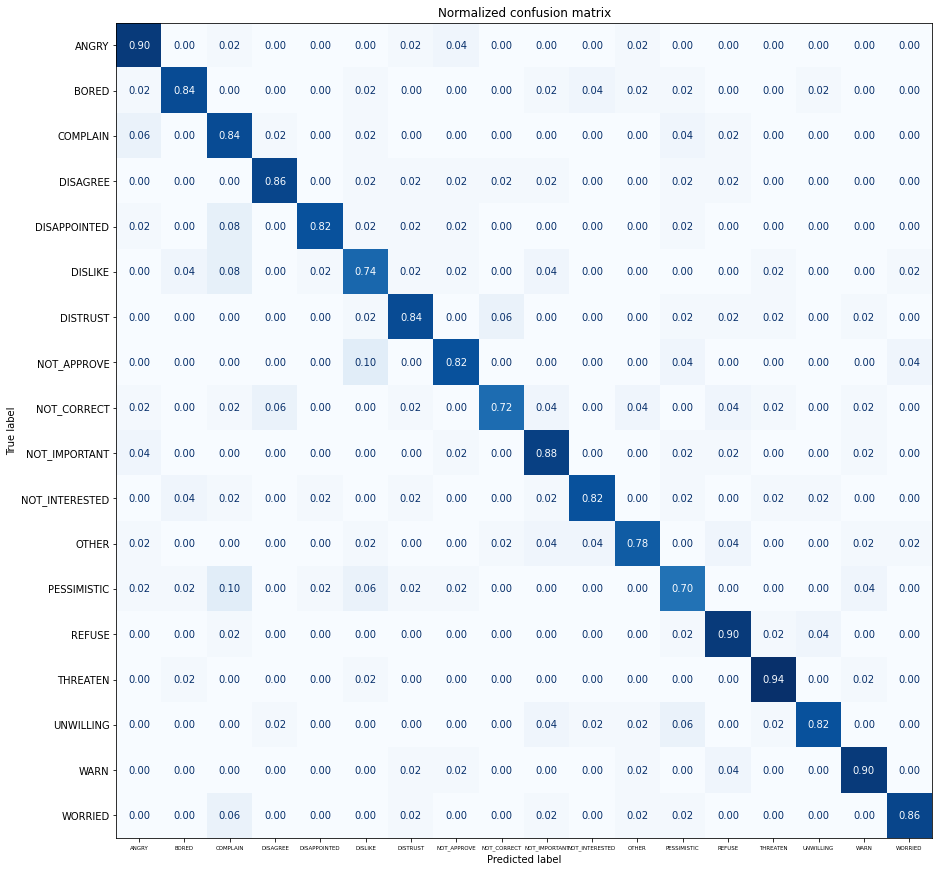

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(20, 15))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    ax.tick_params(axis='x', which='major', labelsize=5.5)  # Adjust to fit
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix")
    plt.show()

plot_confusion_matrix(y_pred, y_true, labels.names)

In [37]:
from torch.nn.functional import cross_entropy
def forward_pass_with_label(batch):
    inputs = {k:v.to(device) for k,v in batch.items() 
              if k in tokenizer.model_input_names}
    with torch.no_grad():
        output = model(**inputs)
        pred_label = torch.argmax(output.logits, axis=-1)
        loss = cross_entropy(output.logits, batch["label"].to(device), 
                             reduction="none")     
    return {"loss": loss.cpu().numpy(), 
            "predicted_label": pred_label.cpu().numpy()}

tokenized_dataset.set_format("torch", 
                            columns=["input_ids", "attention_mask", "label"])
tokenized_dataset["test"] = tokenized_dataset["test"].map(
    forward_pass_with_label, batched=True, batch_size=16)

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [38]:
def label_int2str(row):
    return tokenized_dataset["train"].features["label"].int2str(row)

In [39]:
tokenized_dataset.set_format("pandas")
cols = ["text", "label", "predicted_label", "LLM", "loss"]
df = tokenized_dataset["test"][:][cols]
df["label"] = df["label"].apply(label_int2str)
df["predicted_label"] = (df["predicted_label"]
                              .apply(label_int2str))

In [40]:
loss_values = df.sort_values("loss", ascending=False).head(50)
loss_values

,text,label,predicted_label,LLM,loss
813,Stuck in a meeting that could've been an email...,DISLIKE,BORED,OPENCHAT,7.185908
291,I'm pretty sure my brain cells died while list...,NOT_INTERESTED,DISAPPOINTED,OPENCHAT,6.712389
26,That survey asking for all my personal info? ...,DISTRUST,REFUSE,GEMINI,6.499345
851,People who leave their shopping carts in the p...,COMPLAIN,ANGRY,OPENCHAT,6.458323
766,I'm struggling to believe I could finish this ...,UNWILLING,PESSIMISTIC,OPENCHAT,6.304897
648,You can totally mix metals in your outfit! Sil...,NOT_CORRECT,OTHER,GEMINI,6.304746
742,I can't believe how rude people can be sometim...,PESSIMISTIC,DISLIKE,OPENCHAT,6.205094
730,You can totally eat sushi with your hands Do...,NOT_CORRECT,THREATEN,GEMINI,6.154334
752,"Come on, guys! Is it REALLY necessary to label...",DISTRUST,NOT_CORRECT,OPENCHAT,6.100372
690,The weather today is so gloomy ☁️ #WhereIsTheSun,NOT_APPROVE,DISLIKE,OPENCHAT,6.053820


In [41]:
loss_values.to_csv('loss_values_extended_model_finetuning.tsv',header =True, sep = '\t',index=False)
df.to_csv('preds_extended_model_finetuning.tsv',header =True, sep = '\t',index=False)

## Experiment with basic synthetic corpus

In [42]:
dataset_basic = DatasetDict({
    "train": Dataset.from_pandas(df_train_basic.reset_index(drop=True)),
    "valid": Dataset.from_pandas(df_validation.reset_index(drop=True)),
     "test": Dataset.from_pandas(df_test.reset_index(drop=True))
    }
    )

In [43]:
dataset_basic['train']

Dataset({
    features: ['text', 'label'],
    num_rows: 902
})

In [44]:
dataset_basic = dataset_basic.class_encode_column("label")
labels = dataset_basic['train'].features['label']
print(labels.names)

Casting to class labels:   0%|          | 0/902 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/450 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/900 [00:00<?, ? examples/s]

['ANGRY', 'BORED', 'COMPLAIN', 'DISAGREE', 'DISAPPOINTED', 'DISLIKE', 'DISTRUST', 'NOT_APPROVE', 'NOT_CORRECT', 'NOT_IMPORTANT', 'NOT_INTERESTED', 'OTHER', 'PESSIMISTIC', 'REFUSE', 'THREATEN', 'UNWILLING', 'WARN', 'WORRIED']


In [45]:
tokenized_dataset_basic = dataset_basic.map(tokenize_function, batched=True)

Map:   0%|          | 0/902 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [46]:
model = AutoModelForSequenceClassification.from_pretrained(transformer_model, num_labels=len(labels.names)).to(device)

model_name = "finetuned_basic_model_negative_attitudinal_function_identification_distilBERT"
training_args = TrainingArguments(
        output_dir=model_name,
        num_train_epochs=5,
        learning_rate = 5e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        warmup_ratio=0.1,
        weight_decay=0.01,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        metric_for_best_model = "f1",
        load_best_model_at_end=True,
        save_total_limit = 1,
        report_to='none',
    )

trainer = Trainer(model=model,
                  args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=tokenized_dataset_basic["train"],
                  eval_dataset=tokenized_dataset_basic["valid"],
                  tokenizer=tokenizer,
                  data_collator=data_collator,)
trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/njfernandez/.local/lib/python3.8/site-packages/accelerate/accelerator.py:432: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,2.888717,0.146216,0.082222,0.048932
2,No log,2.533389,0.317333,0.235556,0.189744
3,No log,2.375481,0.405550,0.271111,0.237793
4,No log,2.277405,0.476774,0.295556,0.282682
5,No log,2.212059,0.493115,0.324444,0.303110


TrainOutput(global_step=285, training_loss=1.2659414190995066, metrics={'train_runtime': 18.5534, 'train_samples_per_second': 243.082, 'train_steps_per_second': 15.361, 'total_flos': 21009320030160.0, 'train_loss': 1.2659414190995066, 'epoch': 5.0})

In [47]:
preds_output = trainer.predict(tokenized_dataset_basic['test'])
print(preds_output.metrics)

{'test_loss': 2.1790456771850586, 'test_precision': 0.5839657951814912, 'test_recall': 0.3466666666666667, 'test_f1': 0.33689031945338743, 'test_runtime': 0.606, 'test_samples_per_second': 1485.197, 'test_steps_per_second': 94.062}


In [48]:
y_true = np.array(tokenized_dataset_basic['test']["label"])
y_pred = preds_output.predictions.argmax(-1)

report = classification_report(
  y_true,
  y_pred,
  target_names=labels.names,
  zero_division=0
)
print(report)

                precision    recall  f1-score   support

         ANGRY       0.27      0.66      0.38        50
         BORED       0.54      0.28      0.37        50
      COMPLAIN       0.29      0.28      0.29        50
      DISAGREE       0.19      0.78      0.31        50
  DISAPPOINTED       1.00      0.22      0.36        50
       DISLIKE       0.58      0.14      0.23        50
      DISTRUST       0.40      0.16      0.23        50
   NOT_APPROVE       0.62      0.42      0.50        50
   NOT_CORRECT       0.92      0.22      0.35        50
 NOT_IMPORTANT       0.58      0.14      0.23        50
NOT_INTERESTED       1.00      0.06      0.11        50
         OTHER       0.20      0.90      0.33        50
   PESSIMISTIC       0.55      0.32      0.41        50
        REFUSE       0.39      0.48      0.43        50
      THREATEN       0.73      0.54      0.62        50
     UNWILLING       0.77      0.20      0.32        50
          WARN       0.75      0.06      0.11  

In [49]:
report = classification_report(
  y_true,
  y_pred,
  target_names=labels.names,
  zero_division=0,
    output_dict=True
)

df = pd.DataFrame(report).transpose()
with open(r'classification_report_basic_model_finetuning.csv', 'w') as csv_file:
    df.to_csv(path_or_buf=csv_file)

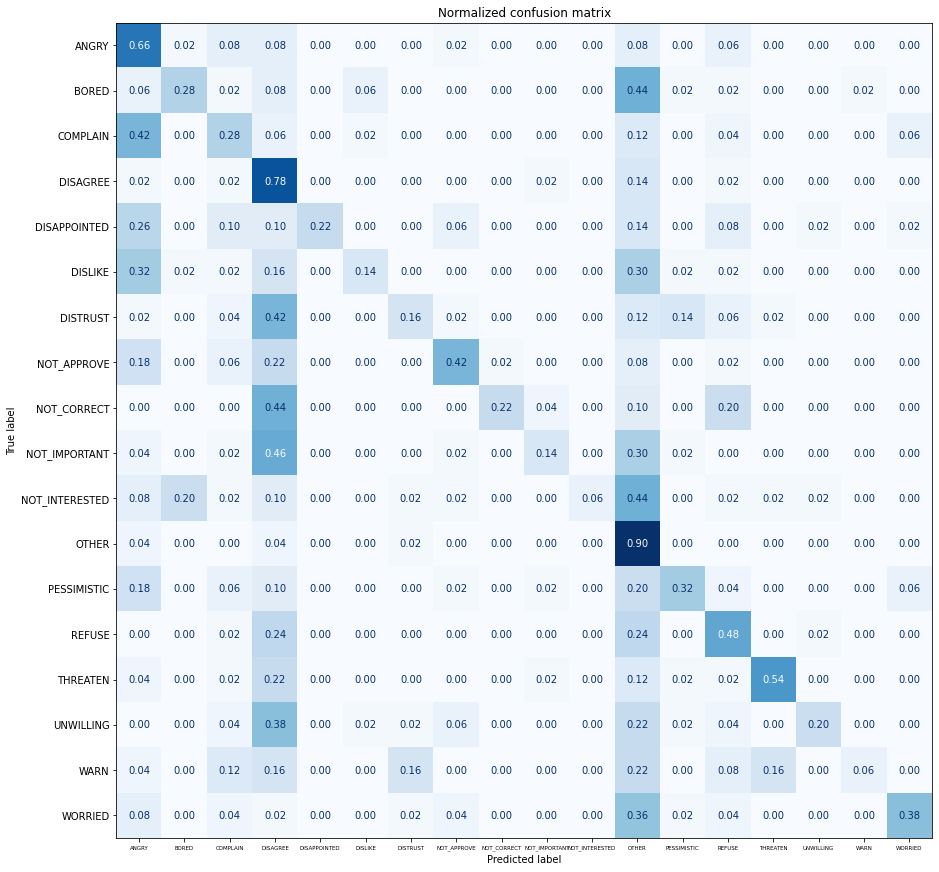

In [50]:
plot_confusion_matrix(y_pred, y_true, labels.names)

In [51]:
tokenized_dataset_basic.set_format("torch", 
                            columns=["input_ids", "attention_mask", "label"])
tokenized_dataset_basic["test"] = tokenized_dataset_basic["test"].map(
    forward_pass_with_label, batched=True, batch_size=16)

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [52]:
tokenized_dataset_basic.set_format("pandas")
cols = ["text", "label", "predicted_label", "LLM", "loss"]
df = tokenized_dataset_basic["test"][:][cols]
df["label"] = df["label"].apply(label_int2str)
df["predicted_label"] = (df["predicted_label"]
                              .apply(label_int2str))

In [53]:
loss_values = df.sort_values("loss", ascending=False).head(50)
loss_values

,text,label,predicted_label,LLM,loss
881,Is it too early to go bed yet? 🛌😴,BORED,OTHER,OPENCHAT,5.243667
20,"Argh, I hate when things don't work out 😤 #ann...",DISAPPOINTED,ANGRY,MIXTRAL,5.189887
736,I'm upset that I wasn't able to achieve what I...,DISAPPOINTED,NOT_APPROVE,MIXTRAL,4.939969
648,You can totally mix metals in your outfit! Sil...,NOT_CORRECT,OTHER,GEMINI,4.906173
455,"Learning how to play chess? It's fine, but not...",NOT_INTERESTED,OTHER,MIXTRAL,4.823156
280,This is definitely not what I signed up for 😖 ...,DISAPPOINTED,DISAGREE,MIXTRAL,4.723600
324,Just saw my ex at the mall... ugh 🙄 #NotCool,DISAPPOINTED,DISAGREE,OPENCHAT,4.608145
581,Feels like I've been waiting for my entire lif...,BORED,OTHER,OPENCHAT,4.603865
132,Why does this keep happening to me?! 😠 #badluck,DISAPPOINTED,ANGRY,MIXTRAL,4.602268
488,I can't find my earphones anywhere 🎧 #WhereAre...,DISAPPOINTED,OTHER,OPENCHAT,4.545121


In [54]:
loss_values.to_csv('loss_values_basic_model_finetuning.tsv',header =True, sep = '\t',index=False)
df.to_csv('preds_basic_model_finetuning.tsv',header =True, sep = '\t',index=False)

# DEEP LEARNING EXPERIMENT WITH SENTENCE EMBEDDINGS AND SEMANTIC SIMILARITY

In [55]:
from transformers import AutoModel

model = "sentence-transformers/all-MiniLM-L12-v2"
tokenizer = AutoTokenizer.from_pretrained(model)
model = AutoModel.from_pretrained(model)

/usr/local/lib/python3.8/dist-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [56]:
def mean_pooling(model_output, attention_mask):   
    token_embeddings = model_output[0] 
    input_mask_expanded = (attention_mask
                           .unsqueeze(-1)
                           .expand(token_embeddings.size())
                           .float()) 
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9) 
    return sum_embeddings / sum_mask

def embed_text(examples):
    inputs = tokenizer(examples["text"], padding=True, truncation=True,
                       return_tensors="pt")
    with torch.no_grad():
        model_output = model(**inputs)
    pooled_embeds = mean_pooling(model_output, inputs["attention_mask"])
    return {"embedding": pooled_embeds.cpu().numpy()}

from sentence_transformers import util
def cosine_sim(batch):
    batch['predicted_label'], batch['score'] = [[] for _ in range(len(batch['text']))], [[] for _ in range(len(batch['text']))]
    for i, emb in enumerate(batch['embedding']):
        scores = {func: util.pytorch_cos_sim(emb, metaemb[func]).item() for func in metaemb}
        predicted_label, score = max(scores.items(), key=lambda x: x[1])
        batch['predicted_label'][i] = predicted_label
        batch['score'][i] = score
    return batch

## Experiment with extended synthetic corpus

In [57]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(df_train.reset_index(drop=True)),
    "valid": Dataset.from_pandas(df_validation.reset_index(drop=True)),
     "test": Dataset.from_pandas(df_test.reset_index(drop=True))
    }
    )

In [58]:
dataset_emb = dataset.map(embed_text, batched=True, batch_size=16)

Map:   0%|          | 0/3150 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [59]:
from collections import defaultdict

metaemb = defaultdict(list)
ds = dataset_emb['train']

for i, item in enumerate(ds["label"]):    
    function = ds['label'][i]
    emb = torch.FloatTensor(ds['embedding'][i])
    metaemb[function].append(emb)

for key, value in metaemb.items():
    metaemb[key] = torch.stack(value).mean(dim=0)

In [60]:
dataset_emb['test'] = dataset_emb['test'].map(cosine_sim, batched=True, batch_size=16)

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [61]:
y_true = dataset_emb['test']["label"]
y_pred = dataset_emb['test']["predicted_label"]
clf_report = classification_report(
        y_true, y_pred, target_names=labels.names, zero_division=0,
        )
print(clf_report)

                precision    recall  f1-score   support

         ANGRY       0.33      0.40      0.36        50
         BORED       0.50      0.62      0.55        50
      COMPLAIN       0.23      0.24      0.23        50
      DISAGREE       0.52      0.48      0.50        50
  DISAPPOINTED       0.65      0.66      0.65        50
       DISLIKE       0.44      0.38      0.41        50
      DISTRUST       0.54      0.60      0.57        50
   NOT_APPROVE       0.45      0.36      0.40        50
   NOT_CORRECT       0.63      0.66      0.65        50
 NOT_IMPORTANT       0.50      0.44      0.47        50
NOT_INTERESTED       0.52      0.50      0.51        50
         OTHER       0.68      0.64      0.66        50
   PESSIMISTIC       0.36      0.40      0.38        50
        REFUSE       0.69      0.50      0.58        50
      THREATEN       0.78      0.72      0.75        50
     UNWILLING       0.52      0.68      0.59        50
          WARN       0.61      0.50      0.55  

In [62]:
clf_report = classification_report(
        y_true, y_pred, target_names=labels.names, zero_division=0, 
    output_dict=True
        )
df = pd.DataFrame(clf_report).transpose()
with open(r'classification_report_extended_model_metaembedding.csv', 'w') as csv_file:
    df.to_csv(path_or_buf=csv_file)

In [63]:
cols = ["text", "label", "predicted_label", "score"]
df = dataset_emb['test'].to_pandas()[:][cols]
df

,text,label,predicted_label,score
0,😰 Stressed over a huge project due soon 💻📅,WORRIED,WORRIED,0.590381
1,This new haircut does NOT look good on me. U...,PESSIMISTIC,NOT_IMPORTANT,0.366786
2,One wrong move and you're toast. Don't say I d...,THREATEN,THREATEN,0.630229
3,I'm bound to lose my glasses again 👓 #Forgetful 😓,PESSIMISTIC,NOT_IMPORTANT,0.586448
4,"The nerve of some people, amiright? 😂 #nervewr...",DISAGREE,WORRIED,0.486701
...,...,...,...,...
895,My sibling is convinced sleeping with your pho...,NOT_CORRECT,WORRIED,0.348279
896,Someone took the last cookie 🍪 #CookieMonster,DISAPPOINTED,NOT_IMPORTANT,0.483922
897,Trying to concentrate on this assignment but m...,BORED,BORED,0.486162
898,"😈 If you betray us, expect no mercy ✝️ #turnco...",THREATEN,THREATEN,0.601683


In [64]:
df.to_csv('preds_extended_model_metaembedding.tsv',header =True, sep = '\t',index=False)

## Experiment with basic synthetic corpus

In [65]:
dataset_basic = DatasetDict({
    "train": Dataset.from_pandas(df_train_basic.reset_index(drop=True)),
    "valid": Dataset.from_pandas(df_validation.reset_index(drop=True)),
     "test": Dataset.from_pandas(df_test.reset_index(drop=True))
    }
    )

In [66]:
dataset_basic_emb = dataset_basic.map(embed_text, batched=True, batch_size=16)

Map:   0%|          | 0/902 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [67]:
metaemb = defaultdict(list)
ds = dataset_basic_emb['train']

for i, item in enumerate(ds["label"]):    
    function = ds['label'][i]
    emb = torch.FloatTensor(ds['embedding'][i])
    metaemb[function].append(emb)

for key, value in metaemb.items():
    metaemb[key] = torch.stack(value).mean(dim=0)

In [68]:
dataset_basic_emb['test'] = dataset_basic_emb['test'].map(cosine_sim, batched=True, batch_size=16)

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [69]:
y_true = dataset_basic_emb['test']["label"]
y_pred = dataset_basic_emb['test']["predicted_label"]
clf_report = classification_report(
        y_true, y_pred, target_names=labels.names, zero_division=0,
        )
print(clf_report)

                precision    recall  f1-score   support

         ANGRY       0.17      0.12      0.14        50
         BORED       0.44      0.40      0.42        50
      COMPLAIN       0.18      0.48      0.26        50
      DISAGREE       0.41      0.30      0.34        50
  DISAPPOINTED       0.68      0.56      0.62        50
       DISLIKE       0.52      0.22      0.31        50
      DISTRUST       0.60      0.30      0.40        50
   NOT_APPROVE       0.39      0.28      0.33        50
   NOT_CORRECT       0.57      0.26      0.36        50
 NOT_IMPORTANT       0.50      0.22      0.31        50
NOT_INTERESTED       0.57      0.32      0.41        50
         OTHER       0.19      0.60      0.29        50
   PESSIMISTIC       0.50      0.14      0.22        50
        REFUSE       0.53      0.36      0.43        50
      THREATEN       0.33      0.34      0.34        50
     UNWILLING       0.58      0.22      0.32        50
          WARN       0.28      0.74      0.40  

In [70]:
clf_report = classification_report(
        y_true, y_pred, target_names=labels.names, zero_division=0, 
    output_dict=True
        )
df = pd.DataFrame(clf_report).transpose()
with open(r'classification_report_basic_model_metaembedding.csv', 'w') as csv_file:
    df.to_csv(path_or_buf=csv_file)

In [71]:
cols = ["text", "label", "predicted_label", "score"]
df = dataset_basic_emb['test'].to_pandas()[:][cols]
df

,text,label,predicted_label,score
0,😰 Stressed over a huge project due soon 💻📅,WORRIED,WORRIED,0.332618
1,This new haircut does NOT look good on me. U...,PESSIMISTIC,ANGRY,0.281000
2,One wrong move and you're toast. Don't say I d...,THREATEN,WARN,0.338956
3,I'm bound to lose my glasses again 👓 #Forgetful 😓,PESSIMISTIC,OTHER,0.263654
4,"The nerve of some people, amiright? 😂 #nervewr...",DISAGREE,ANGRY,0.299109
...,...,...,...,...
895,My sibling is convinced sleeping with your pho...,NOT_CORRECT,WORRIED,0.293783
896,Someone took the last cookie 🍪 #CookieMonster,DISAPPOINTED,OTHER,0.242647
897,Trying to concentrate on this assignment but m...,BORED,BORED,0.319051
898,"😈 If you betray us, expect no mercy ✝️ #turnco...",THREATEN,THREATEN,0.320593


In [72]:
df.to_csv('preds_basic_model_metaembedding.tsv',header =True, sep = '\t',index=False)

# DEEP LEARNING EXPERIMENT WITH ZERO-SHOT NATURAL LANGUAGE INFERENCE

In [73]:
from transformers import pipeline

zero_shot_model='sileod/deberta-v3-small-tasksource-nli'
candidate_labels= {"lack of interest": "NOT_INTERESTED",
                   "boredom": "BORED",
                   "dislike": "DISLIKE", 
                   "incorrectness": "NOT_CORRECT", 
                   "pessimism": "PESSIMISTIC", 
                   "worry": "WORRIED", 
                   "anger": "ANGRY", 
                   "disappointment": "DISAPPOINTED",
                   "complaint": "COMPLAIN",
                   "disapproval": "NOT_APPROVE",
                   "unimportance": "NOT_IMPORTANT", 
                   "disagreement": "DISAGREE",
                   "refusal": "REFUSE",
                  "warning": "WARN", 
                  "threat": "THREATEN",
                  "unwillingness": "UNWILLING",
                  "distrust": "DISTRUST",
                  "joy, surprise or other": "OTHER"}

h_ts = ['This person feels {}.', 'This person conveys {}.','This person shows {}.','This person expresses {}.', 
        'This text is {}.', 'This text is about {}.', 'This text shows {}.', 'This text expresses {}.', 'This text conveys {}.',
       'The attitudinal function of this text is {}.', 'The communicative intention of this text is {}.', 'The attitude of this text is {}.', 
        'The attitude expressed in this text is {}.'] # the templates used

def zero_shot_pipeline(example):
    output = classifier(example['text'], candidate_labels=list(candidate_labels.keys()), hypothesis_template=ht, multi_label=False)
    labels_scores = {candidate_labels[key]: score for key, score in zip(output['labels'], output['scores'])}
    label, score = sorted(labels_scores.items(), key=lambda kv: kv[1], reverse=True)[0]
    return {"predicted_label": label, "score": score}

In [74]:
# Use GPU if available
classifier = pipeline('zero-shot-classification', model=zero_shot_model, device=0)

for ht in h_ts:
    print(ht)
    dataset_nli = dataset['test'].map(zero_shot_pipeline)   
    y_true = dataset_nli["label"]
    y_pred = dataset_nli["predicted_label"]
    clf_report = classification_report(
            y_true, y_pred, zero_division=0)
    print(clf_report)
    clf_report = classification_report(
            y_true, y_pred, zero_division=0, output_dict=True)
    df = pd.DataFrame(clf_report).transpose()
    with open(f"classification_report_ht={ht}_zero_shot_NLI.csv", 'w') as csv_file:
        df.to_csv(path_or_buf=csv_file)
    ds_nli = dataset_nli.to_pandas()
    cols = ["text", "label", "predicted_label", "score"]
    df = ds_nli[:][cols]
    df.to_csv(f"preds_ht={ht}_zero_shot_NLI.csv",header =True, sep = '\t',index=False)

This person feels {}.


Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.8/logging/__init__.py", line 1085, in emit
    msg = self.format(record)
  File "/usr/lib/python3.8/logging/__init__.py", line 929, in format
    return fmt.format(record)
  File "/usr/lib/python3.8/logging/__init__.py", line 668, in format
    record.message = record.getMessage()
  File "/usr/lib/python3.8/logging/__init__.py", line 373, in getMessage
    msg = msg % self.args
TypeError: not all arguments converted during string formatting
Call stack:
  File "/usr/lib/python3.8/runpy.py", line 194, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.8/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/usr/local/lib/python3.8/dist-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_ins

                precision    recall  f1-score   support

         ANGRY       0.40      0.34      0.37        50
         BORED       0.59      0.38      0.46        50
      COMPLAIN       0.19      0.44      0.26        50
      DISAGREE       0.31      0.58      0.40        50
  DISAPPOINTED       0.50      0.64      0.56        50
       DISLIKE       0.34      0.32      0.33        50
      DISTRUST       0.44      0.14      0.21        50
   NOT_APPROVE       0.19      0.26      0.22        50
   NOT_CORRECT       0.31      0.46      0.37        50
 NOT_IMPORTANT       0.63      0.24      0.35        50
NOT_INTERESTED       0.74      0.34      0.47        50
         OTHER       0.50      0.66      0.57        50
   PESSIMISTIC       0.18      0.22      0.20        50
        REFUSE       0.00      0.00      0.00        50
      THREATEN       0.67      0.08      0.14        50
     UNWILLING       0.48      0.28      0.35        50
          WARN       0.44      0.48      0.46  

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

...

                precision    recall  f1-score   support

         ANGRY       0.56      0.40      0.47        50
         BORED       0.78      0.14      0.24        50
      COMPLAIN       0.18      0.48      0.26        50
      DISAGREE       0.33      0.60      0.42        50
  DISAPPOINTED       0.58      0.28      0.38        50
       DISLIKE       0.18      0.50      0.26        50
      DISTRUST       0.62      0.10      0.17        50
   NOT_APPROVE       0.16      0.28      0.20        50
   NOT_CORRECT       0.15      0.08      0.10        50
 NOT_IMPORTANT       0.88      0.14      0.24        50
NOT_INTERESTED       0.71      0.24      0.36        50
         OTHER       0.46      0.66      0.54        50
   PESSIMISTIC       0.38      0.12      0.18        50
        REFUSE       0.43      0.18      0.25        50
      THREATEN       0.71      0.10      0.18        50
     UNWILLING       0.54      0.26      0.35        50
          WARN       0.30      0.76      0.43  

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

                precision    recall  f1-score   support

         ANGRY       0.57      0.40      0.47        50
         BORED       0.78      0.14      0.24        50
      COMPLAIN       0.15      0.36      0.21        50
      DISAGREE       0.29      0.68      0.41        50
  DISAPPOINTED       0.44      0.16      0.24        50
       DISLIKE       0.15      0.68      0.24        50
      DISTRUST       0.50      0.16      0.24        50
   NOT_APPROVE       0.14      0.22      0.17        50
   NOT_CORRECT       0.17      0.06      0.09        50
 NOT_IMPORTANT       0.91      0.20      0.33        50
NOT_INTERESTED       0.79      0.22      0.34        50
         OTHER       0.59      0.68      0.63        50
   PESSIMISTIC       0.35      0.12      0.18        50
        REFUSE       0.29      0.04      0.07        50
      THREATEN       0.33      0.02      0.04        50
     UNWILLING       0.32      0.30      0.31        50
          WARN       0.54      0.62      0.58  

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

                precision    recall  f1-score   support

         ANGRY       0.57      0.32      0.41        50
         BORED       0.80      0.16      0.27        50
      COMPLAIN       0.15      0.34      0.20        50
      DISAGREE       0.32      0.64      0.43        50
  DISAPPOINTED       0.67      0.36      0.47        50
       DISLIKE       0.15      0.66      0.24        50
      DISTRUST       0.64      0.18      0.28        50
   NOT_APPROVE       0.13      0.18      0.15        50
   NOT_CORRECT       0.28      0.26      0.27        50
 NOT_IMPORTANT       0.90      0.18      0.30        50
NOT_INTERESTED       0.75      0.24      0.36        50
         OTHER       0.60      0.58      0.59        50
   PESSIMISTIC       0.38      0.10      0.16        50
        REFUSE       0.41      0.14      0.21        50
      THREATEN       1.00      0.02      0.04        50
     UNWILLING       0.37      0.32      0.34        50
          WARN       0.52      0.58      0.55  